# Programming Exercise: Shallow Embedding

## Import libraries

In [89]:
import torch
from tqdm import tqdm

## Device

In [90]:
device = 'cpu'

## Load graph data

In [91]:
# Load graph from file
A = torch.load('data.pt')

# Get number of nodes
n_nodes = A.shape[0]

# Number of un-ordered node pairs (possible links)
n_pairs = n_nodes*(n_nodes-1)//2

# Get indices of all un-ordered node pairs excluding self-links (shape: 2 x n_pairs)
idx_all_pairs = torch.triu_indices(n_nodes,n_nodes,1)

# Collect all links/non-links in a list (shape: n_pairs)
target = A[idx_all_pairs[0],idx_all_pairs[1]]

## Visualize adjacency matrix

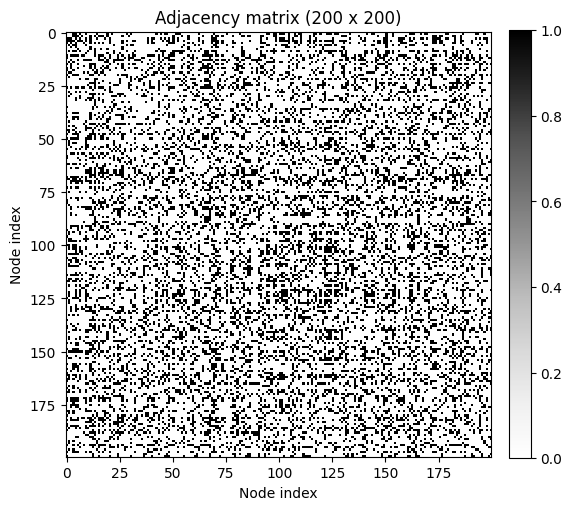

In [92]:
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(A.numpy(), cmap='Greys', interpolation='nearest')
ax.set_title(f'Adjacency matrix ({n_nodes} x {n_nodes})')
ax.set_xlabel('Node index')
ax.set_ylabel('Node index')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

os.makedirs('answers', exist_ok=True)
fig.savefig('answers/adjacency_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Shallow node embedding

In [93]:
class Shallow(torch.nn.Module):
    '''Shallow node embedding

    Args: 
        n_nodes (int): Number of nodes in the graph
        embedding_dim (int): Dimension of the embedding
    '''
    def __init__(self, n_nodes, embedding_dim):
        super().__init__()
        self.embedding = torch.nn.Embedding(n_nodes, embedding_dim=embedding_dim)
        self.bias = torch.nn.Parameter(torch.tensor([0.]))

    def forward(self, rx, tx):
        '''Returns the probability of a links between nodes in lists rx and tx'''
        return torch.sigmoid((self.embedding.weight[rx]*self.embedding.weight[tx]).sum(1) + self.bias)

## Model setup

In [94]:
# Embedding dimension
embedding_dim = 16

# Instantiate the model                
model = Shallow(n_nodes, embedding_dim)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

# Loss function
cross_entropy = torch.nn.BCELoss()

## Fit the model

In [95]:
# Number of gradient steps
max_step = 1500

# Optimization loop
for i in (progress_bar := tqdm(range(max_step))):    
    # Compute probability of each possible link
    link_probability = model(idx_all_pairs[0], idx_all_pairs[1])

    # Cross entropy loss
    loss = cross_entropy(link_probability, target)

    # Gradient step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Display loss on progress bar
    progress_bar.set_description(f'Loss = {loss.item():.3f}')

Loss = 0.031: 100%|██████████| 1500/1500 [00:07<00:00, 208.82it/s]


## Save final estimated link probabilities

In [96]:
link_probability = model(idx_all_pairs[0], idx_all_pairs[1])
torch.save(link_probability, 'link_probabilities.pt')

## Question D.4: Train / validation split + hyperparameter search with Optuna

Random 80 / 20 split of the un-ordered node pairs. Train on the training pairs only and select the best `embedding_dim` (and `lr`, `max_step`) by minimum validation loss using Optuna's TPE sampler.

### 80 / 20 train / validation split of node pairs

In [97]:
# Random 80/20 split of node pairs
n_pairs = idx_all_pairs.shape[1]
perm = torch.randperm(n_pairs, generator=torch.Generator().manual_seed(42))
n_train = int(0.8 * n_pairs)
train_idx, val_idx = perm[:n_train], perm[n_train:]

rx_tr,  tx_tr,  y_tr  = idx_all_pairs[0, train_idx], idx_all_pairs[1, train_idx], target[train_idx]
rx_val, tx_val, y_val = idx_all_pairs[0, val_idx],   idx_all_pairs[1, val_idx],   target[val_idx]

print(f'Total pairs: {n_pairs} | train: {len(train_idx)} | val: {len(val_idx)}')

Total pairs: 19900 | train: 15920 | val: 3980


### Training + evaluation helper

Trains a fresh `Shallow` model on the training pairs only and returns `(train_loss, val_loss)`.

In [98]:
bce = torch.nn.BCELoss()

def train_eval(embedding_dim, lr, max_step, seed=0):
    """Train Shallow on the training pairs and return (train_loss, val_loss)."""
    torch.manual_seed(seed)
    model = Shallow(n_nodes, embedding_dim)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(max_step):
        loss = bce(model(rx_tr, tx_tr), y_tr)
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        train_loss = bce(model(rx_tr, tx_tr), y_tr).item()
        val_loss = bce(model(rx_val, tx_val), y_val).item()
    return train_loss, val_loss

### Optuna hyperparameter search

Search over `embedding_dim`, `lr`, and `max_step`, minimizing validation BCE.

In [99]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    embedding_dim = trial.suggest_categorical('embedding_dim', [2, 4, 8, 16, 32, 64, 128])
    lr = trial.suggest_float('lr', 1e-3, 5e-2, log=True)
    max_step = trial.suggest_int('max_step', 500, 3000, step=500)
    _, val_loss = train_eval(embedding_dim, lr, max_step)
    return val_loss

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=40, show_progress_bar=True)

best_params = study.best_params
best_val_loss = study.best_value
print('Best params:', best_params)
print(f'Best validation loss: {best_val_loss:.4f}')

  0%|          | 0/40 [00:00<?, ?it/s]

Best params: {'embedding_dim': 8, 'lr': 0.012223810830983162, 'max_step': 500}
Best validation loss: 0.2036


### Sweep embedding_dim with best lr / max_step

In [100]:
# Sweep embedding_dim using the best lr / max_step found by Optuna
sweep_dims = [2, 4, 8, 16, 32, 64, 128]
sweep_results = []
for d in sweep_dims:
    tr, vl = train_eval(d, best_params['lr'], best_params['max_step'])
    sweep_results.append((d, tr, vl))
    print(f'dim={d:>3}  train={tr:.4f}  val={vl:.4f}')

dim=  2  train=0.4177  val=0.4365
dim=  4  train=0.2321  val=0.2750
dim=  8  train=0.1087  val=0.2036
dim= 16  train=0.0647  val=0.3421
dim= 32  train=0.0214  val=0.7627
dim= 64  train=0.0361  val=3.0000
dim=128  train=1.3353  val=7.5086


### Plot loss vs embedding_dim

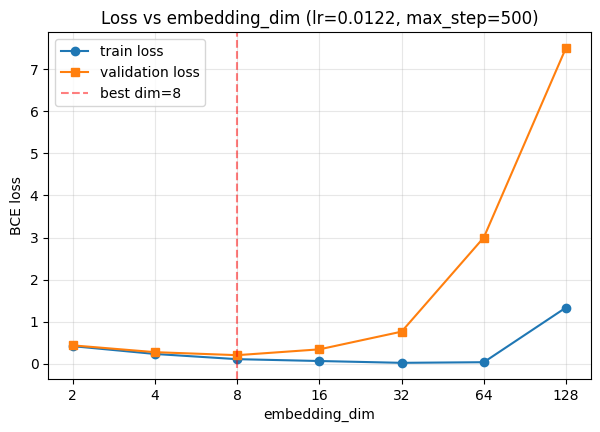

In [101]:
import matplotlib.pyplot as plt

ds, trs, vls = zip(*sweep_results)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ds, trs, 'o-', label='train loss')
ax.plot(ds, vls, 's-', label='validation loss')
ax.set_xscale('log', base=2)
ax.set_xticks(ds); ax.set_xticklabels(ds)
ax.set_xlabel('embedding_dim')
ax.set_ylabel('BCE loss')
ax.set_title(f"Loss vs embedding_dim (lr={best_params['lr']:.4f}, max_step={best_params['max_step']})")
ax.axvline(best_params['embedding_dim'], color='red', ls='--', alpha=0.5,
           label=f"best dim={best_params['embedding_dim']}")
ax.legend(); ax.grid(alpha=0.3)

import os
os.makedirs('answers', exist_ok=True)
fig.savefig('answers/d4_loss_vs_dim.png', dpi=120, bbox_inches='tight')
plt.show()